In [1]:
import scarf

scarf.configure_output(level="ERROR", progress=True)

repository = scarf.cytebase.connect('scarf_docs')
remote_group = repository.open_zarr('tenx_5K_pbmc_rnaseq/data.zarr')

ds = scarf.DataStore(remote_group.store, zarr_mode='r', nthreads=4)
print(ds)

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_S_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_G2M_score', 
            'RNA_doublet_score', 'RNA_cell_cycle_phase', 'RNA_nFeatures', 'RNA_percentRibo', 'RNA_percentMito', 
            'RNA_paris_cluster'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'genome', 'feature_type', 
            'nCells', 'I__hvgs', 'dropOuts'


Legacy state rejected: legacy_feature_contract


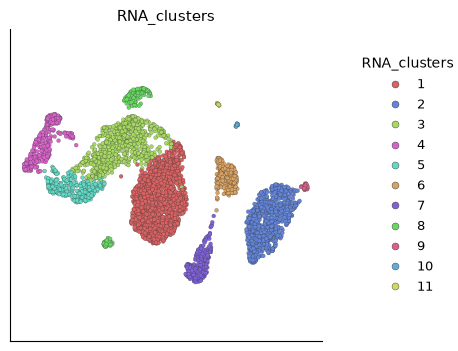

In [2]:
try:
    ds.get_assay_state('RNA')
except scarf.IncompatibleAnalysisStateError as error:
    print('Legacy state rejected:', error.code)

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_clusters',
)

In [3]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import zarr

from scarf.tools.repack_zarr import repack_store

source_uri = (
    "hf://buckets/Nygen/cytebase/scarf_docs/"
    "tenx_5K_pbmc_rnaseq/data.zarr"
)
mount_directory = TemporaryDirectory()
repacked_path = Path(mount_directory.name) / 'counts.zarr'
target_path = Path(mount_directory.name) / 'analysis.zarr'

repack_store(
    source_uri,
    str(repacked_path),
    storage_options={"token": False},
    nthreads=2,
)

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/cluster_hierarchy//children: 1 / 1 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

...

Repacking RNA/artifacts/marker_table//9/stats: 1 / 1 complete

Repacking RNA/artifacts/normalized//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

  RNA/counts: shape=(5025, 33538), dtype=uint32, chunks=(5025, 4791), shards=(5025, 38328)
  RNA/counts: shape=(5025, 33538), dtype=uint32, chunks=(5025, 4791), shards=(5025, 38328)


In [4]:
mounted = scarf.mount_datastore(
    str(repacked_path),
    at=str(target_path),
    default_assay='RNA',
    nthreads=4,
)

matrix_source = zarr.open_group(str(target_path), mode='r').attrs['matrixSource']
print('Target path:', target_path)
print('Target exists:', target_path.exists())
print('Original source URI:', source_uri)
print('Mounted count source:', matrix_source['location'])
print('Mounted assays:', sorted(matrix_source['assays']))

Target path: /tmp/tmpqal9zrxd/analysis.zarr
Target exists: True
Original source URI: hf://buckets/Nygen/cytebase/scarf_docs/tenx_5K_pbmc_rnaseq/data.zarr
Mounted count source: /tmp/tmpqal9zrxd/counts.zarr
Mounted assays: ['RNA']


In [5]:
target_root = zarr.open_group(str(target_path), mode='r')

print('Counts stored in target:', 'counts' in target_root['RNA'])
print('Mounted shape:', mounted.RNA.rawData.shape)

Counts stored in target: False
Mounted shape: (5025, 33538)


In [6]:
mounted_features = mounted.mark_hvgs(
    min_cells=20,
    top_n=500,
    show_plot=False,
    label='mounted_hvgs',
)
normalized = mounted.run_normalization(features=mounted_features)
pca = mounted.run_pca(normalized, dims=15)

mounted.build_embedding_initialization(pca)
ann_index = mounted.build_ann_index(pca)
neighbors = mounted.query_neighbors(ann_index, k=11)
graph = mounted.build_connectivity_map(neighbors)
mounted.run_umap(
    graph=graph,
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label="mounted_UMAP",
)
mounted.run_leiden_clustering(
    graph=graph,
    resolution=0.5,
    label="mounted_clusters",
)

Calculating feature statistics: 30 / 30 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 100 / 100 complete

ArtifactRef(assay='RNA', kind='cluster_labels', artifact_id='337c4177f522...')

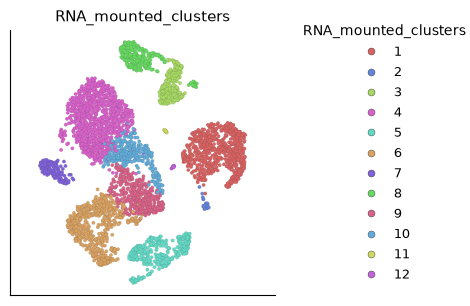

In [7]:
mounted.plots.embedding(
    layout_key="RNA_mounted_UMAP",
    color_by="RNA_mounted_clusters",
)

In [8]:
target_bytes = sum(
    path.stat().st_size
    for path in target_path.rglob("*")
    if path.is_file()
)
logical_count_bytes = int(
    np.prod(mounted.RNA.rawData.shape)
    * mounted.RNA.rawData.dtype.itemsize
)
print("Writable target bytes:", target_bytes)
print("Dense logical count bytes:", logical_count_bytes)

Writable target bytes: 9392771
Dense logical count bytes: 674113800


In [9]:
reopened = scarf.DataStore(
    str(target_path),
    nthreads=4,
)
same_counts = np.array_equal(
    reopened.RNA.rawData[:20, :20].compute(),
    mounted.RNA.rawData[:20, :20].compute(),
)
print('Counts still resolve:', same_counts)
print('Normalization complete:', reopened.inspect_artifact(normalized).complete)

Counts still resolve: True
Normalization complete: True


In [10]:
from pathlib import Path
from tempfile import TemporaryDirectory

scratch_directory = TemporaryDirectory()
scratch_dir = Path(scratch_directory.name) / 'pca_scratch'
pca_without_staging = mounted.run_pca(
    normalized,
    dims=15,
    local_cache=str(scratch_dir),
    update_state=False,
)
staged_bytes = sum(
    path.stat().st_size for path in scratch_dir.rglob('*') if path.is_file()
)
print('Local cache path:', scratch_dir)
print('Staged normalized bytes:', staged_bytes)
print('Local cache present after PCA:', scratch_dir.exists())
print('Reduction reused:', pca_without_staging == pca)

Local cache path: /tmp/tmpfvv_1hzq/pca_scratch
Staged normalized bytes: 0
Local cache present after PCA: False
Reduction reused: True
